In [1]:
import urllib.request
import zipfile
import os
from pathlib import Path
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return
    
    with urllib.request.urlopen(url) as response: # Open the URL and read the response
        with open(zip_path, 'wb') as out_file:
            out_file.write(response.read())
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref: # Open the downloaded zip file and extract its contents
        zip_ref.extractall(extracted_path)
        
    original_file_path = Path(extracted_path) / "SMSSpamCollection" # The original file name inside the zip
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

In [2]:
download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [3]:
import pandas as pd
df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [4]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


In [5]:
def create_balanced_dataset(df):
    num_spam = df[df["Label"] == "spam"].shape[0]
    ham_sampled = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    balanced_df = pd.concat([ham_sampled, df[df["Label"] == "spam"]])
    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


In [6]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

In [7]:
def random_split(df, train_frac, validation_frac):
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)  # Shuffle the DataFrame
    
    train_end = int(train_frac * len(df)) # Calculate the index for the end of the training set
    val_end = train_end + int(validation_frac * len(df)) # Calculate the index for the end of the validation set
    
    train_df = df[:train_end] # Get the training set
    val_df = df[train_end:val_end] # Get the validation set
    test_df = df[val_end:] # Get the test set
    
    return train_df, val_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)

In [8]:
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

In [9]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [10]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):

        self.data = pd.read_csv(csv_file)
        
        self.encoded_texts = [tokenizer.encode(text) for text in self.data["Text"]]
        
        if max_length is None:
            self.max_length = self._longest_encoded_length()  # Determine the maximum length based on the longest encoded text
        
        else: 
            self.max_length = max_length  # Use the provided max_length
            
            self.encoded_text = [  
                encoded_text[:self.max_length]  # Truncate the encoded text to the specified max_length
                for encoded_text in self.encoded_texts
            ]
        
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text)) 
            for encoded_text in self.encoded_texts 
        ]
            # Pad the encoded texts to the max_length using the pad_token_id
        
    def __getitem__(self, index): 
        encoded = self.encoded_texts[index] # Get the encoded text for the given index
        label = self.data.iloc[index]["Label"] # Get the label for the given index
        return (
            torch.tensor(encoded, dtype=torch.long), 
            torch.tensor(label, dtype=torch.long)
        )
        
    def __len__(self):
        return len(self.data)
    
    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length: # Update max_length if the current encoded text is longer
                max_length = encoded_length
        return max_length

In [11]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

In [12]:
print(train_dataset.max_length)

120


In [13]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

In [14]:
from torch.utils.data import DataLoader

num_workers = 0 
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last = False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last = False
)

In [15]:
for input_batch, target_batch in train_loader:
    pass
print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


In [16]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


In [17]:
CHOOSE_MODEL = "gpt2-small (124M)"

INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
"vocab_size": 50257, # Vocabulary size
"context_length": 1024, # Context length
"drop_rate": 0.0, # Dropout rate
"qkv_bias": True # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={BASE_CONFIG['context_length']}`"
)

In [18]:
from gpt_download import download_and_load_gpt2
from load_weights_into_gpt import load_weights_into_gpt
from gpt_model import GPTModel

model_size = CHOOSE_MODEL.split()[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2_model_for_classification_finetuning")

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2_model_for_classification_finetuning\124M\checkpoint
File already exists and is up-to-date: gpt2_model_for_classification_finetuning\124M\encoder.json
File already exists and is up-to-date: gpt2_model_for_classification_finetuning\124M\hparams.json
File already exists and is up-to-date: gpt2_model_for_classification_finetuning\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2_model_for_classification_finetuning\124M\model.ckpt.index
File already exists and is up-to-date: gpt2_model_for_classification_finetuning\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2_model_for_classification_finetuning\124M\vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_key): Linear(in_feature

In [19]:
from generate_text_simple import generate_text_simple
from token_converter import text_to_token_ids, token_ids_to_text

text_1 = "Every effort moves you"

model = model.to(device)

token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(text_1, tokenizer).to(device),
    max_new_tokens=15,
    context_size = BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [20]:
text_2 = (
"Is the following text 'spam'? Answer with 'yes' or 'no':"
" 'You are a winner you have been specially"
" selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(text_2, tokenizer).to(device),
    max_new_tokens=23,
    context_size = BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


In [21]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_key): Linear(in_feature

In [22]:
for param in model.parameters():
    param.requires_grad = False

In [23]:
# instead of retraining the entire model, we will train a new output head where the num of output nodes is equal to the number of classes in our classification task (2 in this case for "ham" and "spam")

torch.manual_seed(123)

num_classes = 2

model.out_head = torch.nn.Linear(      
    in_features=BASE_CONFIG["emb_dim"],    #parameters.requires_grad = True by default for new layers
    out_features=num_classes
)

In [24]:
# it was found that fine-tuning just the final transformer block and the final layer norm along with the new output head gives better results than just training the new output head alone, so we will unfreeze those layers as well

for param in model.transformer_blocks[-1].parameters():
    param.requires_grad = True
    
for param in model.final_norm.parameters():
    param.requires_grad = True

In [25]:
model = model.to(device) # moving to GPU if available again after adding new layers

In [26]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0).to(device)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) # shape: (batch_size, num_tokens)

Inputs: tensor([[5211,  345,  423,  640]], device='cuda:0')
Inputs dimensions: torch.Size([1, 4])


In [27]:
with torch.no_grad():
    outputs = model(inputs)
print("Outputs: \n", outputs)
print("Outputs dimensions:", outputs.shape) # shape: (batch_size, num_tokens, num_classes)

# we will see the o/p dimensions are reduced to 2 from the original vocab size of 50257 as we have added a new output head with out_features=num_classes which is 2 in this case for "ham" and "spam"


Outputs: 
 tensor([[[-1.5883,  0.9920],
         [-3.7208,  7.4510],
         [-2.2642,  6.6005],
         [-3.5965,  3.9889]]], device='cuda:0')
Outputs dimensions: torch.Size([1, 4, 2])


In [28]:
print("Last output token:", outputs[:, -1, :])

# In a causal transformer, each token can only attend to itself and previous tokens.
# The last token therefore has access to all preceding tokens and accumulates the most information
# about the sequence, making it a natural choice for sequence-level tasks like classification.

# Due to causal attention, each token attends only to itself and earlier tokens.
# The final token has access to the entire sequence and thus aggregates the most context,
# so we use it as the sequence representation for classification.

Last output token: tensor([[-3.5965,  3.9889]], device='cuda:0')


In [29]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5965,  3.9889]], device='cuda:0')


In [30]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas, dim=-1).item()
print("Class label:", label)

Class label: 1


In [31]:
logits = outputs[:, -1, :]
label = torch.argmax(logits, dim=-1).item()
print("Class label:", label)

Class label: 1


In [32]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0
    
    if num_batches is None:
        num_batches = len(data_loader)
    
    else:
        num_batches = min(num_batches, len(data_loader))
        
    for i, (input_batch, target_batch) in enumerate(data_loader):
        
        if i < num_batches:
            
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)
            
            with torch.no_grad():
                logits = model(input_batch)[:,-1,:]
                
            predicted_labels = torch.argmax(logits, dim=-1)
            
            correct_predictions += (predicted_labels == target_batch).sum().item()
            num_examples += predicted_labels.shape[0]
            
        else:
            break
    
    return correct_predictions / num_examples

In [33]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(device)

torch.manual_seed(123)

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 47.50%
Validation accuracy: 45.00%
Test accuracy: 48.75%


In [34]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:,-1,:]
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

In [35]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    
    total_loss = 0.0
    
    if num_batches == 0:
        return float('nan')
    
    elif num_batches is None:
        num_batches = len(data_loader)
    
    else:
        num_batches = min(num_batches, len(data_loader))
        
    for i, (input_batch, target_batch) in enumerate(data_loader):
        
        if i < num_batches:
            
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            
            total_loss += loss.item()
            
        else:
            break
        
    return total_loss / num_batches

In [36]:
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

In [37]:
print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 3.070
Validation loss: 2.575
Test loss: 2.314


In [38]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
        
    model.train()
    
    return train_loss, val_loss

In [39]:
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, tokenizer):
    
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1
    
    for epoch in range(num_epochs):
        model.train()
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            examples_seen += input_batch.shape[0]
            global_step += 1

            if global_step%eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}):"
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")
                
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)
        
    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [40]:
import time

start_time = time.time()

torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5

train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
    tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time)/60

print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000):Train loss 2.840, Val loss 2.383
Ep 1 (Step 000050):Train loss 0.632, Val loss 0.648
Ep 1 (Step 000100):Train loss 0.563, Val loss 0.601
Training accuracy: 60.00% | Validation accuracy: 55.00%
Ep 2 (Step 000150):Train loss 0.537, Val loss 0.503
Ep 2 (Step 000200):Train loss 0.442, Val loss 0.414
Ep 2 (Step 000250):Train loss 0.465, Val loss 0.381
Training accuracy: 85.00% | Validation accuracy: 82.50%
Ep 3 (Step 000300):Train loss 0.307, Val loss 0.187
Ep 3 (Step 000350):Train loss 0.285, Val loss 0.107
Training accuracy: 90.00% | Validation accuracy: 97.50%
Ep 4 (Step 000400):Train loss 0.224, Val loss 0.083
Ep 4 (Step 000450):Train loss 0.198, Val loss 0.098
Ep 4 (Step 000500):Train loss 0.174, Val loss 0.075
Training accuracy: 95.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550):Train loss 0.148, Val loss 0.073
Ep 5 (Step 000600):Train loss 0.161, Val loss 0.046
Training accuracy: 95.00% | Validation accuracy: 97.50%
Training completed in 0.71 minutes.


In [41]:
import matplotlib.pyplot as plt
def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0) # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")
    
    fig.tight_layout() 
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

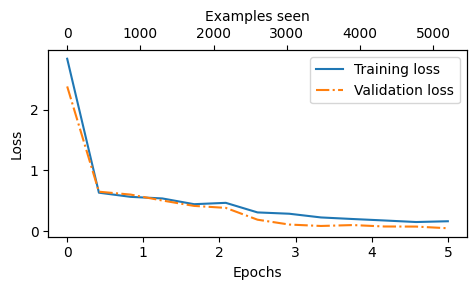

In [42]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

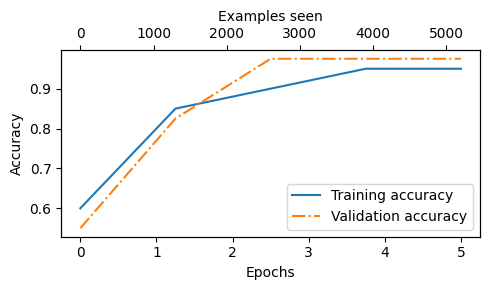

In [43]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))
plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

In [44]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.21%
Validation accuracy: 97.99%
Test accuracy: 96.00%


In [45]:
model.pos_emb.weight.shape

torch.Size([1024, 768])

In [52]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()
    
    input_ids = tokenizer.encode(text) # Encode the input text into token IDs using the tokenizer
    
    max_allowed_context_length = model.pos_emb.weight.shape[0] # Get the context length from the model's positional embedding layer
    
    input_ids = input_ids[:min(max_length, max_allowed_context_length)] # Truncate the input token IDs to the maximum allowed context length
    
    input_ids += [pad_token_id] * (max_length - len(input_ids)) # Pad the input token IDs to the max_length using the pad_token_id
    
    input_ids = torch.tensor(input_ids).unsqueeze(0).to(device) # Convert the input token IDs to a tensor and add a batch dimension
    
    with torch.no_grad():
        logits = model(input_ids)[:,-1,:] # Get the logits from the model for the last token in the sequence because it has access to the entire sequence due to causal attention
        
    predicted_label = torch.argmax(logits, dim=-1).item() # Get the predicted class label by taking the argmax of the logits
    
    return "spam" if predicted_label == 1 else "not spam" # Return "spam" if the predicted label is 1, otherwise return "not spam"   
    

In [53]:
text_1 = (
"You are a winner you have been specially"
" selected to receive $1000 cash or a $2000 award."
)
print(classify_review(
text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [54]:
text_2 = (
"Hey, just wanted to check if we're still on"
" for dinner tonight? Let me know!"
)
print(classify_review(
text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


In [56]:
torch.save(model.state_dict(),"review_classifier.pth")

In [57]:
model_state_dict = torch.load("review_classifier.pth")
model.load_state_dict(model_state_dict)

<All keys matched successfully>